In [1]:
import os
import numpy as np
import scipy as sp
import pandas as pd
from datetime import date
import marineHeatWaves as mhw
import netCDF4 as nc
import datetime
import matplotlib.pyplot as plt
from tqdm import notebook
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor
time=pd.date_range('2021-7-1','2021-9-30')

$ RUN\quad IN\quad HPC $
# TO DO
Calculate&Draw $Q_{2021_{ShortwaveRadiation}}$、$Q_{2021_{LongwaveRadiation}}$、$Q_{2021_{LatentHeatFlux}}$、$Q_{2021_{SensibleHeatFlux}}$、$Q_{Clim_{ShortwaveRadiation}}$、$Q_{Clim_{LongwaveRadiation}}$、$Q_{Clim_{LatentHeatFlux}}$、$Q_{Clim_{SensibleHeatFlux}}$

$Q_{2021_{ShortwaveRadiation}}$、$Q_{2021_{LongwaveRadiation}}$、$Q_{2021_{LatentHeatFlux}}$、$Q_{2021_{SensibleHeatFlux}}$

In [2]:
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')[time2021ind]#ShortwaveRadiation
strs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')[time2021ind]#LongwaveRadiation
slhfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')[time2021ind]#LatentHeatFlux
sshfs_2021=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')[time2021ind]#SensibleHeatFlux
del times,time2021ind

读取$Q_{ShortwaveRadiation}$、$Q_{LongwaveRadiation}$、$Q_{LatentHeatFlux}$、$Q_{SensibleHeatFlux}$

In [3]:
ssrs=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/ssrs.npy')#ShortwaveRadiation
strs=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/strs.npy')#LongwaveRadiation
slhfs=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/slhfs.npy')#LatentHeatFlux
sshfs=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/new/sshfs.npy')#SensibleHeatFlux
times=pd.to_datetime(np.load("/lustre/home/yuhanxue/data/ERA/0.25area/re/timess.npy",allow_pickle=True))

Calculate Climatology

In [4]:
t = np.arange(date(1993,1,1).toordinal(),date(2021,12,31).toordinal()+1)
def mlds(dat):
    global t
    try:
        mhws, clim = mhw.detect(t,dat,climatologyPeriod=[1993,2019])
        return clim['seas']
    except:
        return np.array([np.nan]*10592)
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=7)
    ans=np.array(list(pool.map(mlds,dat)))
    del pool
    return ans
def onetime(dat):
    ans=np.array(list(map(list_map,dat)))
    return ans

In [5]:
pool = ProcessPoolExecutor(max_workers=6)
strs_a=np.swapaxes(strs,0,1)
strs_a=np.swapaxes(strs_a,1,2)
strs_clim=np.array(list(pool.map(list_map,strs_a)))
del pool

pool = ProcessPoolExecutor(max_workers=6)
slhfs_a=np.swapaxes(slhfs,0,1)
slhfs_a=np.swapaxes(slhfs_a,1,2)
slhfs_clim=np.array(list(pool.map(list_map,slhfs_a)))
del pool

pool = ProcessPoolExecutor(max_workers=6)
sshfs_a=np.swapaxes(sshfs,0,1)
sshfs_a=np.swapaxes(sshfs_a,1,2)
sshfs_clim=np.array(list(pool.map(list_map,sshfs_a)))
del pool

pool = ProcessPoolExecutor(max_workers=6)
ssrs_a=np.swapaxes(ssrs,0,1)
ssrs_a=np.swapaxes(ssrs_a,1,2)
ssrs_clim=np.array(list(pool.map(list_map,ssrs_a)))
del pool

In [ ]:
time2021ind=(times.year==2021)&((times.month==7)|(times.month==8)|(times.month==9))
ssrs_clim_2021=ssrs_clim[:,:,time2021ind]
strs_clim_2021=strs_clim[:,:,time2021ind]
sshfs_clim_2021=sshfs_clim[:,:,time2021ind]
slhfs_clim_2021=slhfs_clim[:,:,time2021ind]

In [ ]:
mltt=np.load('12_10mltt.npy')

Text(0.5, 0.98, 'NEP(165°W~130°W,35°N~50°N) Q')

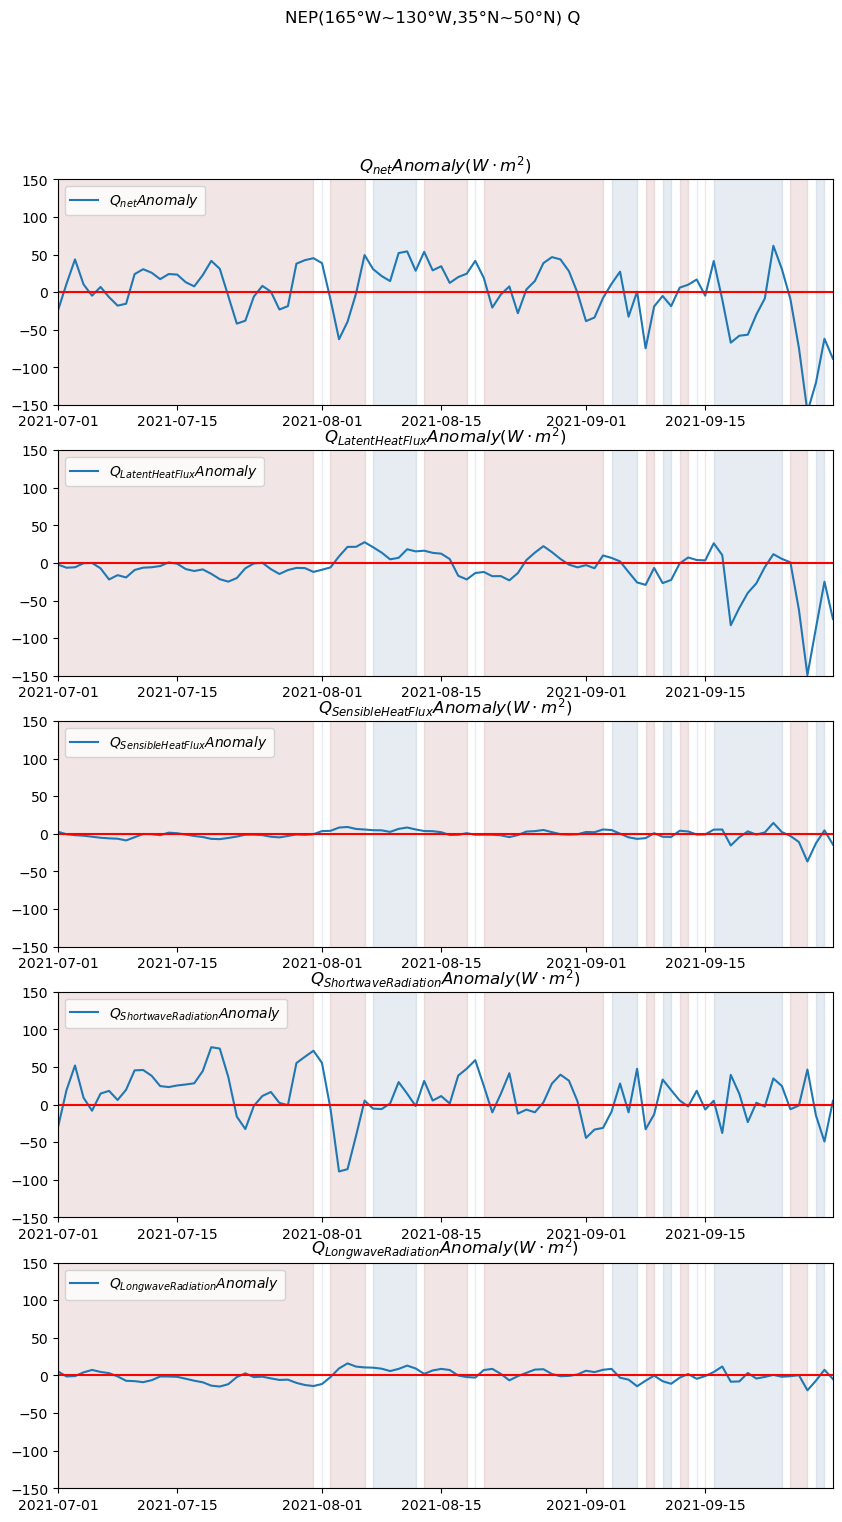

In [ ]:
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000

plt.figure(figsize=[10,17])
plt.subplot(5,1,1)
plt.title('$Q_{net}Anomaly(W\cdot m^2)$')
plt.plot(time,np.nanmean(np.nanmean(slhfs_2021+sshfs_2021+ssrs_2021+strs_2021,axis=1),axis=1)/3600-np.nanmean(np.nanmean(slhfs_clim_2021+sshfs_clim_2021+ssrs_clim_2021+strs_clim_2021,axis=0),axis=0)/3600,label='$Q_{net}Anomaly$')
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-150,150)
plt.yticks(np.arange(-150,151,50))
plt.xlim(time[0],time[-1])
plt.legend(loc='upper left')

plt.subplot(5,1,2)
plt.title('$Q_{LatentHeatFlux}Anomaly(W\cdot m^2)$')
plt.plot(time,np.nanmean(np.nanmean(slhfs_2021,axis=1),axis=1)/3600-np.nanmean(np.nanmean(slhfs_clim_2021,axis=0),axis=0)/3600,label='$Q_{LatentHeatFlux}Anomaly$')
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-150,150)
plt.yticks(np.arange(-150,151,50))
plt.xlim(time[0],time[-1])
plt.legend(loc='upper left')

plt.subplot(5,1,3)
plt.title('$Q_{SensibleHeatFlux}Anomaly(W\cdot m^2)$')
plt.plot(time,np.nanmean(np.nanmean(sshfs_2021,axis=1),axis=1)/3600-np.nanmean(np.nanmean(sshfs_clim_2021,axis=0),axis=0)/3600,label='$Q_{SensibleHeatFlux}Anomaly$')
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-150,150)
plt.yticks(np.arange(-150,151,50))
plt.xlim(time[0],time[-1])
plt.legend(loc='upper left')

plt.subplot(5,1,4)
plt.title('$Q_{ShortwaveRadiation}Anomaly(W\cdot m^2)$')
plt.plot(time,np.nanmean(np.nanmean(ssrs_2021,axis=1),axis=1)/3600-np.nanmean(np.nanmean(ssrs_clim_2021,axis=0),axis=0)/3600,label='$Q_{ShortwaveRadiation}Anomaly$')
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-150,150)
plt.yticks(np.arange(-150,151,50))
plt.xlim(time[0],time[-1])
plt.legend(loc='upper left')

plt.subplot(5,1,5)
plt.title('$Q_{LongwaveRadiation} Anomaly (W\cdot m^2)$')
plt.plot(time,np.nanmean(np.nanmean(strs_2021,axis=1),axis=1)/3600-np.nanmean(np.nanmean(strs_clim_2021,axis=0),axis=0)/3600,label='$Q_{LongwaveRadiation}Anomaly$')
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')
plt.ylim(-150,150)
plt.yticks(np.arange(-150,151,50))
plt.xlim(time[0],time[-1])
plt.legend(loc='upper left')
plt.suptitle('NEP(165°W~130°W,35°N~50°N) Q')

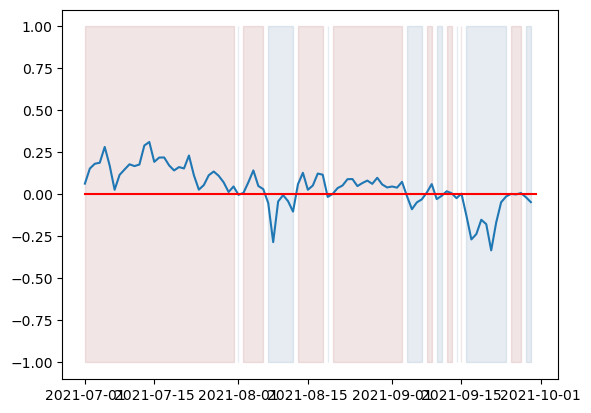

In [ ]:
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1
y0[:]=-1
plt.plot(time[:-1],np.nanmean(np.nanmean(mltt,axis=1),axis=1))
plt.plot(time,np.array([0]*time.shape[0]),'r')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0>0,alpha=0.1,color='#840000')
plt.fill_between(time[:-1],y0[:-1],y1[:-1],where=np.nanmean(np.nanmean(mltt,axis=1),axis=1)-0<0,alpha=0.1,color='#10457e')